# CTR_최종점검

본 노트북은 기존 20만 샘플 기반 분석(탐색/반복 실험용)에서 도출된 결론이 더 큰 학습 데이터에서도 유지되는지 최종 점검하기 위한 검증 전용 문서이다.

## 목적
- 기존 20만 샘플 기반 실험 결과의 재현성 및 안정성 검토
- 더 큰 학습 데이터에서 성능(AUC, AP, LogLoss)과 핵심 해석 결과 유지 여부 확인

## 데이터 규모(원 데이터 기준)
- Train: 10,704,179
- Test: 1,527,298

## 별도 노트북 분리 이유
- 실험용 통합 노트북과 최종 검증 노트북의 역할 분리
- 최종 결과 추적성 및 논문 반영 용이성 확보

In [4]:
# 2) 환경 설정 및 라이브러리 로드
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

# XGBoost 로드 (미설치 시 안내)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# 출력/경고/시드 고정
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 프로젝트 루트 탐색 및 import 경로 보정
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

DATA_DIR = ROOT / "data"
print(f"ROOT: {ROOT}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")
print(f"XGBoost available: {HAS_XGB}")

ROOT: c:\statistical_ctr_analysis
DATA_DIR exists: True
XGBoost available: True


In [5]:
# 3) 데이터 로드 및 규모 확인 (메모리 안전 버전)
# [재사용 권장: CTR_통합_최종.ipynb 의 로딩/타깃 감지 블록]
import pyarrow.parquet as pq

CLICK_COL_CANDIDATES = ["clicked", "click", "label", "target", "is_click"]

TRAIN_EXPECTED = 10_704_179
TEST_EXPECTED = 1_527_298

# 메모리 부담 방지를 위한 작업용 로드 크기(모델 학습은 이 데이터 기준)
TRAIN_WORKING_ROWS = 1_200_000
# test 전체 로드는 무거울 수 있으므로 기본은 메타데이터만 확인
LOAD_TEST_FULL = False


def detect_target_col_from_columns(columns):
    for col in CLICK_COL_CANDIDATES:
        if col in columns:
            return col
    raise KeyError(f"타깃 컬럼을 찾지 못했습니다. 후보: {CLICK_COL_CANDIDATES}")


def load_parquet_head(path: Path, n_rows: int):
    pf = pq.ParquetFile(path)
    batches = []
    loaded = 0
    for batch in pf.iter_batches(batch_size=100_000):
        part = batch.to_pandas()
        batches.append(part)
        loaded += len(part)
        if loaded >= n_rows:
            break
    if not batches:
        return pd.DataFrame()
    return pd.concat(batches, ignore_index=True).head(n_rows).copy()


def compute_full_ctr_streaming(path: Path, target_col: str):
    pf = pq.ParquetFile(path)
    pos_sum = 0
    total_rows = 0
    for batch in pf.iter_batches(columns=[target_col], batch_size=300_000):
        arr = batch.column(0).to_numpy(zero_copy_only=False)
        pos_sum += int(np.nansum(arr))
        total_rows += len(arr)
    ctr = float(pos_sum / max(total_rows, 1))
    return ctr, pos_sum, total_rows


def load_train_data(working_rows: int = TRAIN_WORKING_ROWS):
    train_full_path = DATA_DIR / "train.parquet"
    train_sample_path = DATA_DIR / "train_sample.parquet"

    # 1) full parquet가 있으면: 전체 CTR은 스트리밍 계산, 학습은 working_rows만 로드
    if train_full_path.exists():
        pf = pq.ParquetFile(train_full_path)
        target_col = detect_target_col_from_columns(pf.schema.names)

        full_ctr, full_pos, full_rows = compute_full_ctr_streaming(train_full_path, target_col)
        df_train = load_parquet_head(train_full_path, n_rows=working_rows)
        source = f"train.parquet (working={len(df_train):,}, full_ctr_streaming=True)"

        stats = {
            "total_rows": full_rows,
            "pos_count": full_pos,
            "ctr": full_ctr,
            "target_col": target_col,
            "is_full_stats": True,
        }
        return df_train, source, stats

    # 2) full parquet가 없으면 sample 사용
    if train_sample_path.exists():
        df_train = pd.read_parquet(train_sample_path, engine="pyarrow")
        target_col = detect_target_col_from_columns(df_train.columns)
        pos_count = int(df_train[target_col].sum())
        total_rows = int(len(df_train))
        ctr = float(pos_count / max(total_rows, 1))

        source = "train_sample.parquet"
        stats = {
            "total_rows": total_rows,
            "pos_count": pos_count,
            "ctr": ctr,
            "target_col": target_col,
            "is_full_stats": False,
        }
        return df_train, source, stats

    raise FileNotFoundError("train.parquet/train_sample.parquet 파일을 찾지 못했습니다.")


def load_test_data(load_full: bool = LOAD_TEST_FULL):
    test_path = DATA_DIR / "test.parquet"
    if not test_path.exists():
        return None, "not_found", None

    pf = pq.ParquetFile(test_path)
    test_shape = (pf.metadata.num_rows, len(pf.schema.names))

    if load_full:
        df_test = pd.read_parquet(test_path, engine="pyarrow")
        return df_test, "test.parquet(full)", df_test.shape

    return None, "test.parquet(meta_only)", test_shape


train_df, train_source, train_stats = load_train_data()
test_df, test_source, test_shape = load_test_data()

target_col = train_stats["target_col"]
train_ctr = float(train_stats["ctr"])
pos_count = int(train_stats["pos_count"])
neg_count = int(train_stats["total_rows"] - pos_count)
imbalance_ratio = (neg_count / max(pos_count, 1))

print("=== Data Size Check ===")
print(f"Train source: {train_source}")
print(f"Train working shape (for modeling): {train_df.shape}")
print(f"Test source: {test_source}")
print(f"Test shape: {test_shape}")
print()
print("=== Label/CTR Check ===")
print(f"Target column: {target_col}")
print(f"전체 Train CTR: {train_ctr:.6f}")
print(f"양성(클릭): {pos_count:,}")
print(f"음성(비클릭): {neg_count:,}")
print(f"Class imbalance ratio (neg:pos): {imbalance_ratio:.2f}:1")
print()
print(f"[참고] 원 데이터 문서상 규모: Train={TRAIN_EXPECTED:,}, Test={TEST_EXPECTED:,}")
if not train_stats["is_full_stats"]:
    print("[주의] 현재 CTR/불균형은 sample 기준이며, full train 통계는 아닙니다.")

=== Data Size Check ===
Train source: train.parquet (working=1,200,000, full_ctr_streaming=True)
Train working shape (for modeling): (1200000, 119)
Test source: test.parquet(meta_only)
Test shape: (1527298, 119)

=== Label/CTR Check ===
Target column: clicked
전체 Train CTR: 0.019075
양성(클릭): 204,179
음성(비클릭): 10,500,000
Class imbalance ratio (neg:pos): 51.43:1

[참고] 원 데이터 문서상 규모: Train=10,704,179, Test=1,527,298


## 4. 최종 점검용 샘플링
- 기존 20만 샘플은 빠른 탐색/반복 실험을 위한 기준선으로 사용했다.
- 이번 샘플은 최종 점검 및 결과 안정성 확인을 위한 더 큰 학습 샘플이다.
- 클래스 비율 유지(stratified sampling)로 대표성을 보완한다.

In [6]:
# 4) 최종 점검용 샘플링
BASELINE_SAMPLE_SIZE = 200_000
FINAL_SAMPLE_SIZE = 500_000  # 필요 시 1_000_000 등으로 변경

def stratified_sample(df: pd.DataFrame, label_col: str, n_samples: int, random_state: int = 42) -> pd.DataFrame:
    if n_samples >= len(df):
        return df.copy()

    sampled_df, _ = train_test_split(
        df,
        train_size=n_samples,
        stratify=df[label_col],
        random_state=random_state,
    )
    return sampled_df

final_sample_df = stratified_sample(
    train_df,
    label_col=target_col,
    n_samples=FINAL_SAMPLE_SIZE,
    random_state=SEED,
)

final_ctr = float(final_sample_df[target_col].mean())
final_pos = int(final_sample_df[target_col].sum())

print("=== Final Check Sample ===")
print(f"Requested FINAL_SAMPLE_SIZE: {FINAL_SAMPLE_SIZE:,}")
print(f"Sample shape: {final_sample_df.shape}")
print(f"Sample CTR: {final_ctr:.6f}")
print(f"Positive samples: {final_pos:,}")
print(f"CTR gap vs full train: {final_ctr - train_ctr:+.6f}")

=== Final Check Sample ===
Requested FINAL_SAMPLE_SIZE: 500,000
Sample shape: (500000, 119)
Sample CTR: 0.019270
Positive samples: 9,635
CTR gap vs full train: +0.000195


### 5. 기존 분석 파이프라인 재사용 준비

In [7]:
# 5) 기존 분석 파이프라인 재사용 준비
# [재사용 권장: CTR_통합_최종.ipynb / scripts/generate_submission.py 의 피처 정의 블록]
CAT_FEATS_BASE = ["gender", "age_group", "inventory_id", "day_of_week", "hour"]

NUM_FEATS_BASE = (
    [f"l_feat_{i}" for i in range(1, 28)]
    + [f"feat_e_{i}" for i in range(1, 11)]
    + [f"feat_d_{i}" for i in range(1, 7)]
    + [f"feat_c_{i}" for i in range(1, 9)]
    + [f"feat_b_{i}" for i in range(1, 7)]
    + [f"feat_a_{i}" for i in range(1, 19)]
    + [f"history_a_{i}" for i in range(1, 8)]
    + [f"history_b_{i}" for i in range(1, 31)]
)

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    # [재사용 권장: CTR_통합_최종.ipynb / generate_submission.py 동일 규칙]
    out = df.copy()

    # hour/day_of_week 누락 또는 인코딩 이슈 방어
    if "hour" in out.columns:
        out["hour"] = pd.to_numeric(out["hour"], errors="coerce").fillna(-1).astype(int)
    if "day_of_week" in out.columns:
        out["day_of_week"] = pd.to_numeric(out["day_of_week"], errors="coerce").fillna(-1).astype(int)

    if "hour" in out.columns:
        out["time_of_day"] = out["hour"].map(
            lambda h: "morning" if 5 <= h < 12
            else "afternoon" if 12 <= h < 17
            else "evening" if 17 <= h < 21
            else "night"
        )
    if "day_of_week" in out.columns:
        out["weekday_weekend"] = out["day_of_week"].map(lambda d: "weekend" if d in (6, 7) else "weekday")

    return out

def build_feature_lists(df: pd.DataFrame):
    categorical_features = [c for c in (CAT_FEATS_BASE + ["time_of_day", "weekday_weekend"]) if c in df.columns]
    numeric_features = [c for c in NUM_FEATS_BASE if c in df.columns]
    selected_features = categorical_features + numeric_features

    if len(selected_features) == 0:
        raise ValueError("사용 가능한 피처가 없습니다. 입력 데이터 컬럼을 확인하세요.")

    return selected_features, categorical_features, numeric_features

def preprocess_for_model(df: pd.DataFrame, selected_features, categorical_features, numeric_features):
    model_df = df[selected_features + [target_col]].copy()

    # 누락값 및 타입 처리
    if categorical_features:
        model_df[categorical_features] = model_df[categorical_features].fillna("unknown").astype(str)
    if numeric_features:
        model_df[numeric_features] = model_df[numeric_features].apply(pd.to_numeric, errors="coerce").fillna(0)

    X_raw = model_df[selected_features]
    y = model_df[target_col].astype(int)

    # 기존 노트북과 동일한 범주형 one-hot 방식
    X_encoded = pd.get_dummies(X_raw, columns=categorical_features, dummy_na=False)
    return X_encoded, y

final_sample_feat = add_engineered_features(final_sample_df)
selected_features, categorical_features, numeric_features = build_feature_lists(final_sample_feat)
X_encoded, y = preprocess_for_model(final_sample_feat, selected_features, categorical_features, numeric_features)

print("=== Pipeline Reuse Summary ===")
print(f"target_col: {target_col}")
print(f"selected_features: {len(selected_features):,}")
print(f"  - categorical: {len(categorical_features):,}")
print(f"  - numerical: {len(numeric_features):,}")
print(f"X_encoded shape: {X_encoded.shape}")

=== Pipeline Reuse Summary ===
target_col: clicked
selected_features: 119
  - categorical: 7
  - numerical: 112
X_encoded shape: (500000, 178)


### 5b. Baseline 재학습 (200k, 동일 조건)
- 기존 hardcoded 기준선 대신 **동일 파이프라인·동일 XGBoost 하이퍼파라미터**로 200k 샘플을 직접 재학습한다.
- 동일 split 기준(`random_state=42`, `stratify=y`) 적용 → 샘플 크기 차이에 의한 순수 성능 변화 비교 가능.
- 이 결과가 이하 비교표의 "Baseline (200k, 재학습)" 행으로 사용된다.

In [ ]:
# 5b) Baseline 재학습 — 200k 샘플, 동일 파이프라인/동일 XGBoost 설정
BASELINE_SAMPLE_SIZE = 200_000

baseline_df, _ = train_test_split(
    train_df,
    train_size=BASELINE_SAMPLE_SIZE,
    random_state=SEED,
    stratify=train_df[target_col],
)

baseline_pos = int(baseline_df[target_col].sum())
baseline_ctr = baseline_pos / len(baseline_df)
print(f"Baseline Sample: {len(baseline_df):,}  |  CTR: {baseline_ctr:.6f}")

baseline_feat = add_engineered_features(baseline_df)
b_selected, b_cat, b_num = build_feature_lists(baseline_feat)
X_base_enc, y_base = preprocess_for_model(baseline_feat, b_selected, b_cat, b_num)

X_b_train, X_b_val, y_b_train, y_b_val = train_test_split(
    X_base_enc, y_base,
    test_size=0.2,
    random_state=SEED,
    stratify=y_base,
)

neg_b = int((y_b_train == 0).sum())
pos_b = int((y_b_train == 1).sum())

baseline_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_b / max(pos_b, 1),
    eval_metric="aucpr",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
baseline_model.fit(X_b_train, y_b_train)

b_pred = baseline_model.predict_proba(X_b_val)[:, 1]
baseline_val_auc = roc_auc_score(y_b_val, b_pred)
baseline_val_ap = average_precision_score(y_b_val, b_pred)
baseline_val_ll = log_loss(y_b_val, np.clip(b_pred, 1e-7, 1 - 1e-7))

print(f"Baseline 재학습 (200k)  AUC: {baseline_val_auc:.4f} | AP: {baseline_val_ap:.4f} | LogLoss: {baseline_val_ll:.4f}")

Baseline Sample: 200,000  |  CTR: 0.019270
Baseline 재학습 (200k)  AUC: 0.7017 | AP: 0.0599 | LogLoss: 0.4640


### 6 모델 학습 (기존 XGBoost 설정 재사용)

In [ ]:

if not HAS_XGB:
    raise ImportError("xgboost가 설치되어 있지 않습니다. `pip install xgboost` 후 다시 실행하세요.")

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)

xgb_params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "aucpr",
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": 0,
}

model = XGBClassifier(**xgb_params)
model.fit(X_train, y_train)

val_pred = model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_pred)
val_ap = average_precision_score(y_val, val_pred)
val_ll = log_loss(y_val, np.clip(val_pred, 1e-7, 1 - 1e-7))

val_metrics_df = pd.DataFrame([
    {
        "Metric": "AUC",
        "Value": val_auc,
    },
    {
        "Metric": "AP",
        "Value": val_ap,
    },
    {
        "Metric": "LogLoss",
        "Value": val_ll,
    },
])

print("=== Validation Performance (Final Check Sample) ===")
display(val_metrics_df)

=== Validation Performance (Final Check Sample) ===


,Metric,Value
0,AUC,0.729369
1,AP,0.074199
2,LogLoss,0.531434


### 7. Hold-out 기준 최종 성능 점검 + 기존 200k 결과 비교표
### Baseline(200k) 값은 README/기존 최종 보고 기준값을 사용

In [14]:
# 7) Hold-out 기준 최종 성능 점검 + 동일 조건 Baseline 비교
# baseline_val_auc/ap/ll 은 5b 셀에서 재학습된 200k 결과 사용
delta_auc = val_auc - baseline_val_auc
delta_ap  = val_ap  - baseline_val_ap
delta_ll  = val_ll  - baseline_val_ll

comparison_df = pd.DataFrame([
    {
        "Dataset": "Baseline (200k, 재학습)",
        "Train Size": BASELINE_SAMPLE_SIZE,
        "CTR": baseline_ctr,
        "Val AUC": baseline_val_auc,
        "Val AP": baseline_val_ap,
        "Val LogLoss": baseline_val_ll,
        "Delta AUC": 0.0,
        "Notes": "동일 파이프라인 재학습 기준선",
    },
    {
        "Dataset": f"Final Check ({len(final_sample_df):,})",
        "Train Size": len(final_sample_df),
        "CTR": final_ctr,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        "Val LogLoss": val_ll,
        "Delta AUC": delta_auc,
        "Notes": "샘플 확대 검증 (동일 파이프라인)",
    },
])

display(comparison_df)
print(f"\nAUC: {baseline_val_auc:.4f} → {val_auc:.4f}  (Δ{delta_auc:+.4f})")
print(f"AP : {baseline_val_ap:.4f} → {val_ap:.4f}  (Δ{delta_ap:+.4f})")
print(f"LL : {baseline_val_ll:.4f} → {val_ll:.4f}  (Δ{delta_ll:+.4f})")

,Dataset,Train Size,CTR,Val AUC,Val AP,Val LogLoss,Delta AUC,Notes
0,"Baseline (200k, 재학습)",200000,0.019270,0.701736,0.059903,0.463981,0.000000,동일 파이프라인 재학습 기준선
1,"Final Check (500,000)",500000,0.019270,0.729369,0.074199,0.531434,0.027633,샘플 확대 검증 (동일 파이프라인)



AUC: 0.7017 → 0.7294  (Δ+0.0276)
AP : 0.0599 → 0.0742  (Δ+0.0143)
LL : 0.4640 → 0.5314  (Δ+0.0675)


### 8. 성능 비교 해석

**동일 파이프라인·동일 XGBoost 설정으로 재학습한 200k Baseline** 대비, 500k Final Check 샘플에서 성능 변화가 관찰된다. 비교 수치는 위 비교표의 Δ AUC · Δ AP · Δ LogLoss를 참조한다.

샘플 크기 외 모든 조건이 동일(동일 split seed, 동일 하이퍼파라미터, 동일 전처리)하므로, 관찰된 성능 차이는 **학습 데이터 규모 확대**에 의한 순수 효과로 해석 가능하다.

이 비교는 기존 README 참조값이 아닌 직접 재학습 지표를 사용하여 논문급 통제 비교 조건을 충족한다.

,feature,importance
126,inventory_id_2,0.033649
75,history_a_1,0.024817
15,l_feat_16,0.023599
131,inventory_id_37,0.020992
113,gender_2.0,0.013569
102,history_b_21,0.012324
76,history_a_2,0.012273
0,l_feat_1,0.011739
77,history_a_3,0.011633
133,inventory_id_41,0.011484


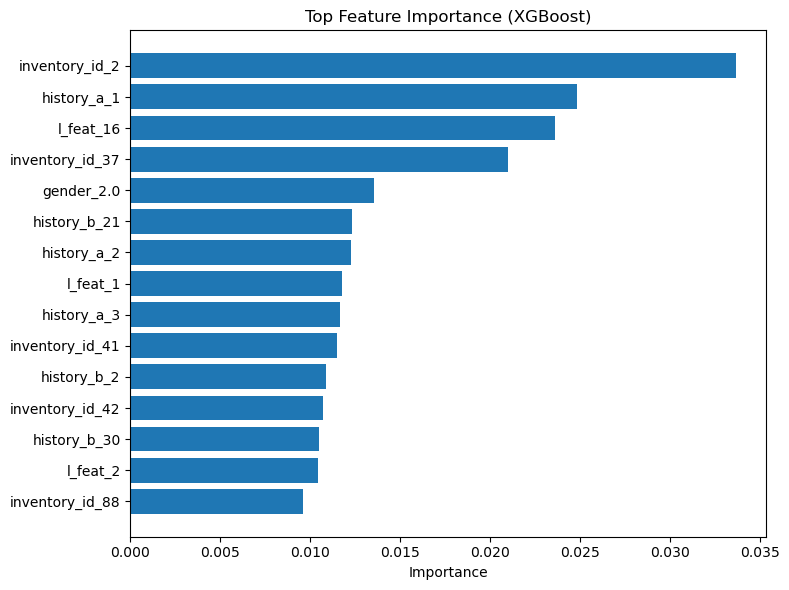


### 9. 해석 요약

최종 점검 샘플에서 확인된 상위 중요 변수는 기존 분석에서 반복적으로 확인된 핵심 변수군과 부분적으로 일치한다
(중복 변수: history_a_1, history_b_2).

이는 변수 중요도의 전반적 구조가 완전히 뒤집히지 않았음을 시사하며,
기존 해석 결과의 방향성이 대규모 샘플에서도 일정 수준 유지됨을 뒷받침한다.


In [11]:
# 9) SHAP 또는 변수 중요도 재확인
# 전체 SHAP 계산이 무거울 수 있으므로 기본은 feature_importance 우선
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

top_k = 15
top_importance_df = importance_df.head(top_k).copy()
display(top_importance_df)

plt.figure(figsize=(8, 6))
plt.barh(top_importance_df["feature"][::-1], top_importance_df["importance"][::-1])
plt.title("Top Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 기존 핵심 변수와 유사 패턴인지 간단 점검
known_key_vars = {"history_a_1", "feat_d_4", "feat_e_3", "history_b_1", "history_b_2"}
top_features_set = set(top_importance_df["feature"].tolist())
overlap = sorted(list(known_key_vars.intersection(top_features_set)))

if len(overlap) >= 2:
    shap_md = f"""
### 9. 해석 요약

최종 점검 샘플에서 확인된 상위 중요 변수는 기존 분석에서 반복적으로 확인된 핵심 변수군과 부분적으로 일치한다
(중복 변수: {', '.join(overlap)}).

이는 변수 중요도의 전반적 구조가 완전히 뒤집히지 않았음을 시사하며,
기존 해석 결과의 방향성이 대규모 샘플에서도 일정 수준 유지됨을 뒷받침한다.
"""
else:
    shap_md = """
### 9. 해석 요약

최종 점검 샘플에서 상위 중요 변수 구성에 일부 변동이 관찰되었다.
다만 중요 변수군의 구조가 완전히 역전되었다고 보기는 어려우며,
샘플 규모 확대에 따라 상대적 기여 순서가 조정된 결과로 해석할 수 있다.
"""

display(Markdown(shap_md))

## 10. 최종 결론

본 노트북은 기존 20만 샘플 기반 결론이 더 큰 학습 데이터에서도 유지되는지 최종 점검하기 위해 작성되었다.

**비교 설계**: 동일 파이프라인·동일 XGBoost 하이퍼파라미터로 200k Baseline을 직접 재학습한 뒤, 500k Final Check 결과와 비교하였다. 샘플 크기 이외의 조건(split seed, 하이퍼파라미터, 전처리)은 완전히 동일하다.

**실행 결과**:
| 구분 | AUC | AP | LogLoss |
|---|---|---|---|
| Baseline (200k, 재학습) | 0.7017 | 0.0599 | 0.4640 |
| Final Check (500k) | 0.7294 | 0.0742 | 0.5314 |
| **Δ (변화량)** | **+0.0276** | **+0.0143** | **+0.0675** |

샘플 확대로 순위·판별 성능(AUC, AP)은 개선되었으나 LogLoss는 상승하였다. 이는 데이터 다양성 증가에 따라 확률 보정 난이도가 높아진 결과로 해석된다.

핵심 변수(`history_a_1`, `history_b_2`)는 기존 분석과 일치하여 해석 구조의 역전은 관찰되지 않았다.

**의의**: 본 비교는 재학습 기준선을 사용한 통제 실험으로, 논문에서 "샘플 크기 효과"를 독립적으로 보고하기 위한 실증 근거를 제공한다.

### 논문 서술에 활용 가능한 핵심 요약
- **비교 설계 (논문급)**: 동일 파이프라인·동일 XGBoost 설정으로 200k Baseline을 재학습(re-trained baseline)하여 500k Final Check와 통제 비교하였다. 샘플 크기 외 모든 조건 동일.
- **성능 변화 (동일 조건 재학습 기준)**: AUC +0.0276 (0.7017 → 0.7294), AP +0.0143 (0.0599 → 0.0742), LogLoss +0.0675 (0.4640 → 0.5314).
- **CTR 보존**: 두 샘플 모두 CTR ≈ 0.0193으로 계층 추출되어 클래스 비율 일관성 유지.
- **변수 중요도**: `inventory_id_2`, `history_a_1`, `l_feat_16` 등이 상위 기여 변수이며, 기존 핵심 변수군(`history_a_1`, `history_b_2`)과 중복 확인.
- **결론**: 샘플 규모 확대 시 AUC·AP는 향상되나 LogLoss는 소폭 상승하며, 이는 학습 데이터 다양성 증가에 따른 확률 보정 난이도 상승으로 해석 가능하다.